# 2. Catalog-wide analyses over all rare cancers

Actionability, shared molecular dependencies, the druggability gap, the etiology landscape, and the hereditary syndrome map, computed over the full rare cancer catalog.

In [1]:
import os, sys
def _find_repo():
    p = os.getcwd()
    for _ in range(6):
        if os.path.exists(os.path.join(p, "anveshar", "__init__.py")):
            return p
        p = os.path.dirname(p)
    return None
REPO = _find_repo()
if REPO and REPO not in sys.path:
    sys.path.insert(0, REPO)
import anveshar
print("anveshar loaded from", os.path.dirname(anveshar.__file__))

anveshar loaded from /data1/lesliec/vijay/github/anveshar/anveshar


In [2]:
from anveshar import analysis
import pandas as pd, matplotlib.pyplot as plt

/data1/massaguj/yarlagad/conda/envs/annotforimst/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Actionability: which rare cancers have a borrowable approved therapy

In [3]:
s = analysis.actionability_summary()
print(s["n_actionable"], "of", s["n_rare_cancers"], f"({s['pct_actionable']}%) actionable;",
      s["n_tissue_agnostic"], "tissue-agnostic")
pd.DataFrame(s["top_drugs"], columns=["drug", "n_rare_cancers"]).head(10)

99 of 504 (20%) actionable; 24 tissue-agnostic


,drug,n_rare_cancers
0,Imatinib,19
1,Sotorasib,18
2,Dabrafenib plus trametinib,15
3,Tazemetostat,12
4,Ivosidenib,7
5,Crizotinib or alectinib,6
6,Crizotinib,6
7,Avapritinib,5
8,Trastuzumab deruxtecan,3
9,Larotrectinib or entrectinib,3


## Shared molecular dependencies (the cross-translation map)

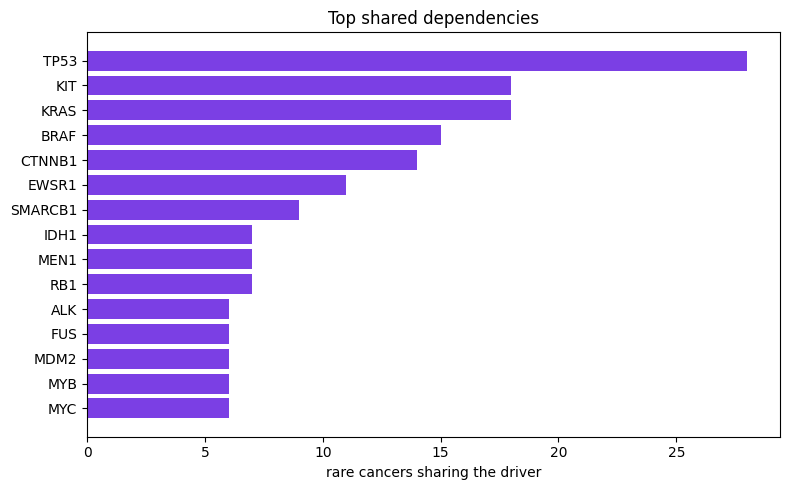

In [4]:
shared = analysis.catalog_shared_drivers()
top = shared[:15]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([g for g, _ in top][::-1], [len(v) for _, v in top][::-1], color="#7b3fe4")
ax.set_xlabel("rare cancers sharing the driver"); ax.set_title("Top shared dependencies"); plt.tight_layout()

## Druggability gap: shared but undrugged dependencies (unmet need)

In [5]:
g = analysis.druggability_summary()
print(g["n_unmet_shared"], "of", g["n_shared_drivers"], "shared dependencies have no approved drug")
pd.DataFrame(g["top_unmet"], columns=["gene", "n_rare_cancers"])

70 of 84 shared dependencies have no approved drug


,gene,n_rare_cancers
0,TP53,28
1,CTNNB1,14
2,EWSR1,11
3,MEN1,7
4,RB1,7
5,FUS,6
6,MDM2,6
7,MYB,6
8,MYC,6
9,ATF1,5


## Etiology landscape

In [6]:
e = analysis.etiology_landscape()
pd.DataFrame([(k, v["count"]) for k, v in e.items()], columns=["category", "n_rare_cancers"])

,category,n_rare_cancers
0,Infectious,35
1,Environmental or carcinogen,79
2,Hereditary syndrome,99
3,Precursor lesion or transformation,64
4,Cause not established,298


## Hereditary predisposition syndromes

In [7]:
pd.DataFrame([(syn, len(cs)) for syn, cs in analysis.hereditary_syndrome_map()],
             columns=["syndrome", "n_rare_cancers"])

,syndrome,n_rare_cancers
0,Li-Fraumeni syndrome (TP53),20
1,Neurofibromatosis type 1 (NF1),20
2,Multiple endocrine neoplasia (MEN),19
3,Lynch syndrome (mismatch repair),12
4,Familial adenomatous polyposis (APC),11
5,von Hippel-Lindau (VHL),8
6,Succinate dehydrogenase deficiency (SDHx),7
7,Tuberous sclerosis complex,7
8,Beckwith-Wiedemann syndrome,6
9,Retinoblastoma predisposition (RB1),5


---
*Disclaimer: this notebook produces research and educational analysis of public data, not medical advice. Confidence and validation scores summarize evidence strength, not the probability of benefit for any individual. Every clinical decision must be made by a qualified health care provider, ideally within a clinical trial.*

*Developed by Dig Vijay Kumar Yarlagadda, [digvijayky.com](https://digvijayky.com).*